# Durable and non-durable assets with adjustment frictions: EGM(FUES) vs NEGM(FUES)

**Paper**: Dobrescu and Shanker (2022), [*A fast upper envelope scan method for discrete-continuous dynamic programming*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4181302)

We solve a lifecycle model (Application 2 in Dobrescu and Shanker, 2022) in which an agent holds a liquid financial asset and an illiquid durable asset subject to adjustment frictions. The durable provides flow utility — it can be thought of as housing. Each period the agent decides whether to adjust the durable stock, then chooses non-durable consumption and savings. We compare two solution methods:

- **EGM(FUES)** inverts the Euler equations for both the adjuster and the keeper. The keeper's problem is a standard 1D discrete-continuous EGM with FUES. For the adjuster, each durable choice $H_{\succ}$ maps to multiple continuation assets $a_{\succ}$ via root-finding on the housing FOC and analytical inversion of the consumption FOC ([Dobrescu and Shanker, 2022](https://doi.org/10.2139/ssrn.4181660)).
- **NEGM(FUES)** nests the keeper's 1D EGM solution inside a golden-section search over the adjuster's durable choice $H_{\succ}$ ([Druedahl, 2021](https://doi.org/10.1016/j.jedc.2021.104107)).

Both methods use FUES for the keeper's upper envelope; they differ in how the **adjuster stage** recovers the housing policy.

| Method | Adjuster stage | UE (keeper) | UE (adjuster) |
|--------|----------------|:-----------:|:-------------:|
| **EGM(FUES)** | EGM: find all roots of housing FOC, invert consumption FOC analytically | FUES | FUES |
| **NEGM(FUES)** | Golden-section search over $H_{\succ}$, with $a_{\succ}$ from keeper's optimal policy (via EGM + FUES) | FUES | — |

The keeper stage and the tenure stage (discrete adjust-or-keep choice + income shock) are identical under both methods. The comparison isolates the accuracy benefit of EGM inversion for the adjuster, where non-monotone policies and multiple locally optimal candidates create a cloud of crossing value-function segments. MSS ([Iskhakov et al., 2017](https://doi.org/10.3982/QE643)) requires monotone segments separated by identifiable crossing points. LTM ([Druedahl, 2021](https://doi.org/10.1016/j.jedc.2021.104107)) requires the endogenous-to-exogenous mapping to be one-to-one within each segment. FUES imposes neither requirement.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/cobb_douglas'
print('Ready')

Ready


## 2. Solve

We use the Cobb-Douglas utility specification $\mathrm{u}(c, H_{\succ}) = \bigl(c^\alpha\,(H_{\succ} + \bar{d})^{1-\alpha}\bigr)^{1-\rho}\!/(1{-}\rho)$ following [Druedahl (2021)](https://doi.org/10.1016/j.jedc.2021.104107). The income process is AR(1) in logs: $\log z_{\succ} = \rho_z \log z + \sigma_z\,\varepsilon_{\succ}$, $\varepsilon_{\succ} \sim N(0,1)$, discretised to `N_wage` nodes via Tauchen's method. Parameters and grid settings are loaded from YAML; `setting_overrides` and `calib_overrides` edit these at runtime before instantiating a solvable model.

The syntax `_mo = {('adjuster_cons', 'cntn_to_dcsn_mover', 'upper_envelope'): method}` is used to pass the `upper_envelope` method name to the `cntn_to_dcsn_mover` of the `adjuster_cons` stage each period. Parameters and settings are applied "globally" across all stages in the model.  

In [ ]:
# Parameters and settings
param_settings_for_nb = {
    'settings': {
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 600, 'n_a': 600, 'n_h': 600, 'T': 70,
    },
    'calibration': {
        't0': 20, 'tau': 0.07,
        'sigma_w': 0.11, 'phi_w': 0.86,
        'beta': 0.91, 'R': 1.04, 'rho': 2.5,
    },
}

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout

# Solve under each method
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        _mo = {
            ('adjuster_cons',
             'cntn_to_dcsn_mover',
             'upper_envelope'): method,
        }
        nest, grids = solve(
            SYNTAX, ue_method=_mo,
            verbose=False, progress='bar',
            draw=param_settings_for_nb)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


Solving: 100%|██████████| 51/51 [01:08<00:00,  1.35s/it, age=20, avg_adj_ms=71, avg_keeper_ms=233]

NEGM(FUES)



Solving: 100%|██████████| 51/51 [01:06<00:00,  1.30s/it, age=20, avg_adj_ms=71, avg_keeper_ms=238]


  51 periods, ages 20–70
  r=0.045, R=1.04, r_H=0, R_H=1.0, beta=0.89, alpha=0.7, rho=2.5, d_ubar=0.001, delta=0, tau=0.07, theta=1.3498, lambdas=[4.329982, 0.610214, -0.0209832, 0.0003132, -1.72e-06, 0.0199949, 4.76e-05], tau_av=30
  n_a=600, n_h=600, n_w=600, N_wage=4

  Method            Keeper    Adjuster      Tenure     Total
                (ms/period)  (ms/period)  (ms/period)     (sec)
  ────────────────────────────────────────────────────────────
  EGM(FUES)            233          71         783        69
  NEGM(FUES)           238          71         824        66


## 3. Adjuster policies

We now plot adjuster financial assets $a_{\succ}$ and housing choice $H_{\succ}$ as functions of market resources $w_{\text{adj}}$ for the adjuster. First start with the model solved with EGM and FUES for both the adjuster and the keeper.

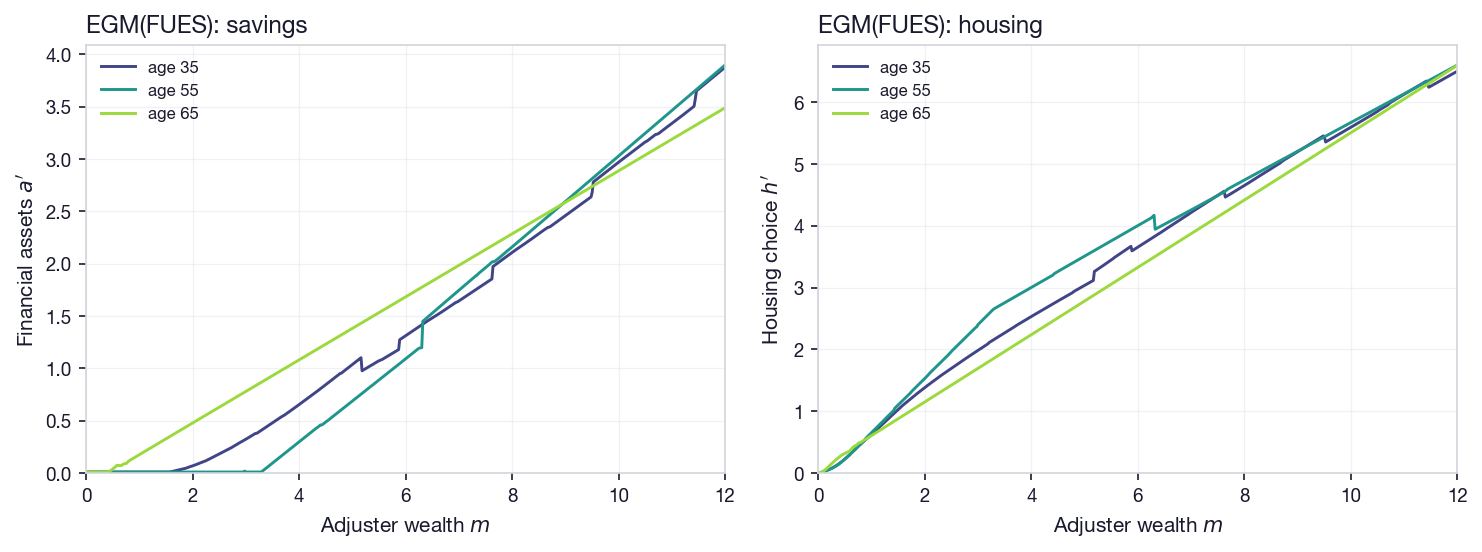

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[35, 55, 65], methods_filter=['FUES'], xlim =12)

Now we use nested EGM (with FUES for the keeper problem only). Golden-section search replaces the EGM in the adjuster stage.

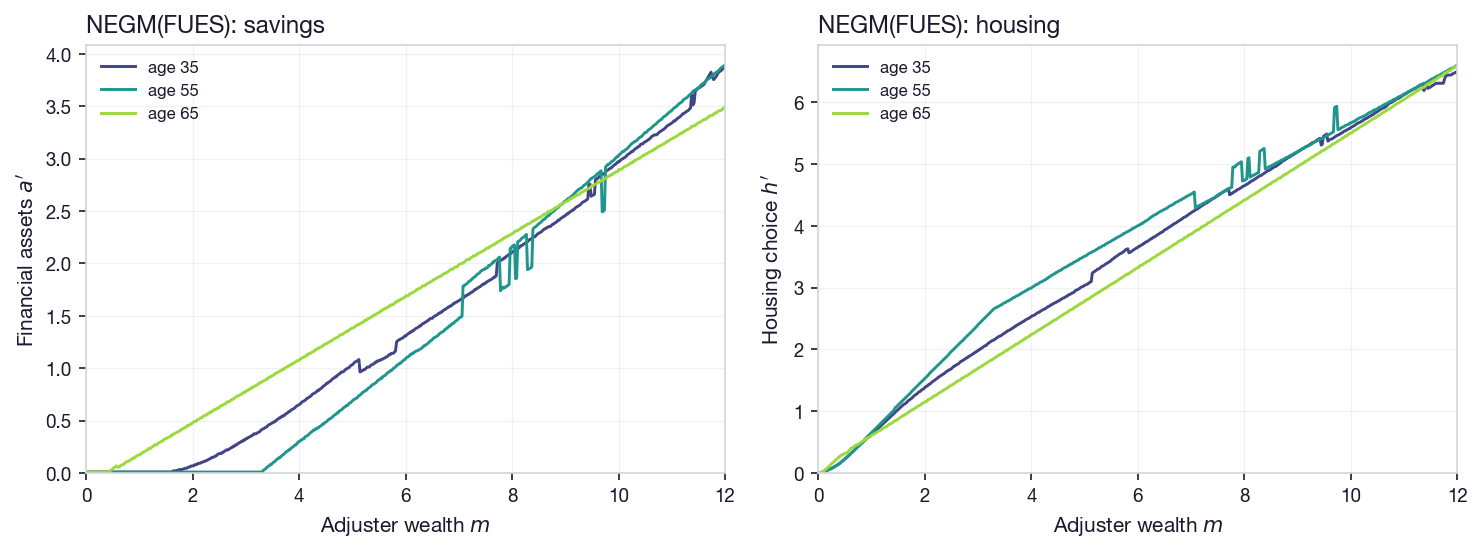

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[35, 55, 65], methods_filter=['NEGM'], xlim =12)

## 4. Adjuster EGM grid

The EGM over the $H_{\succ}$ grid produces an endogenous wealth grid where **multiple housing choices map to the same wealth level**. The left panel shows raw EGM candidates for financial assets $a_{\succ}$; the middle panel shows housing $H_{\succ}$; the right panel shows the value correspondence $\mathrm{v}(\hat{m})$. Each scatter point is one $(H_{\succ}, a_{\succ})$ root of the coupled FOCs. FUES scans this dense cloud to recover the upper envelope in a single pass. MSS and LTM require locally isolated points on the exogenous grid to separate unique segments before interpolating over each of them; because of multiple endogenous grid for each exogenous grid point, neither method can identify these segments.

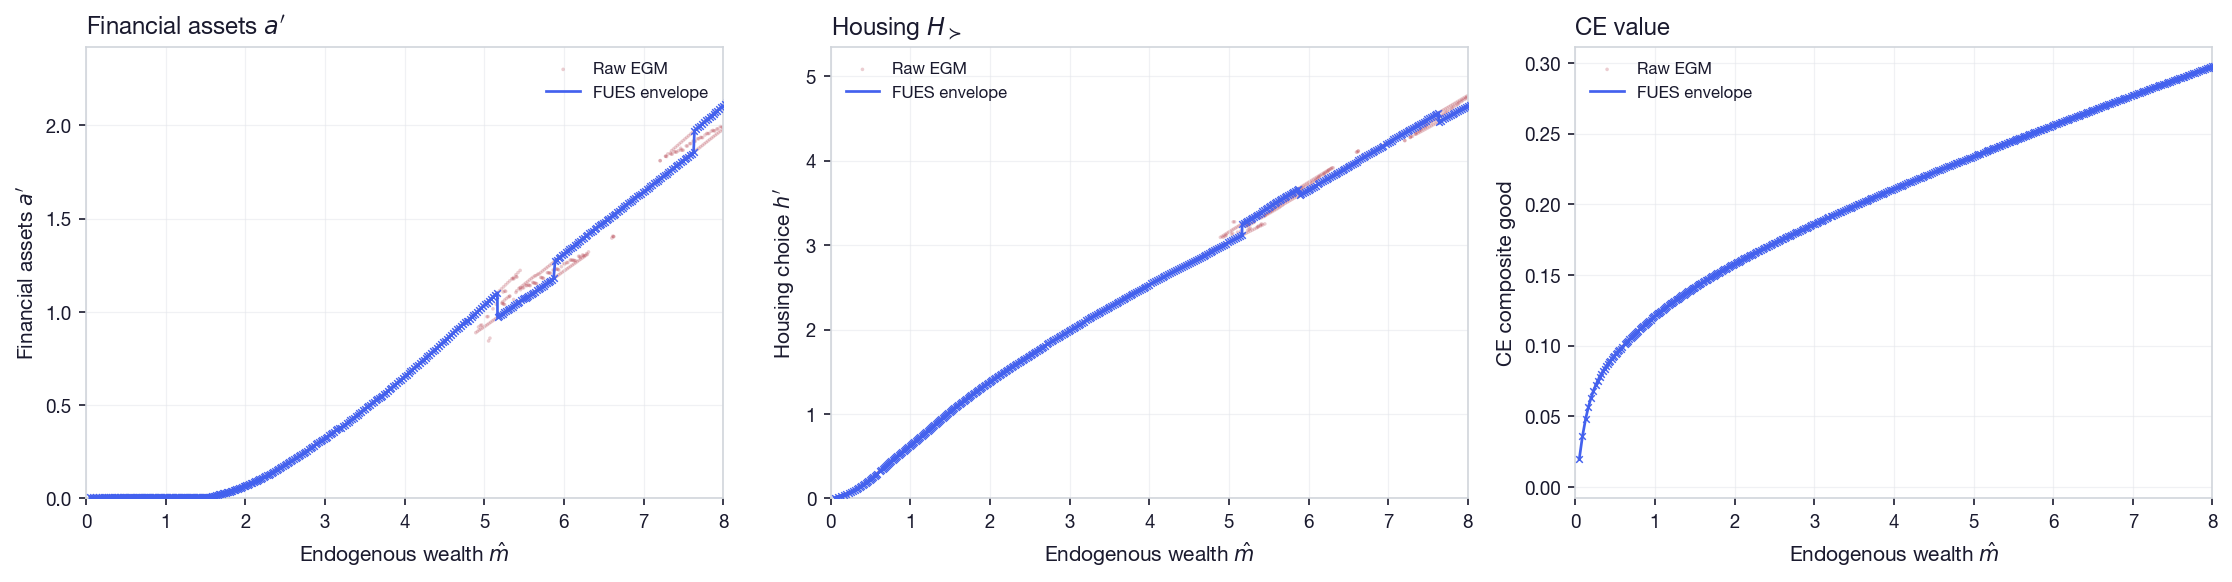

In [5]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=35, xlim =8)

Interactive versions of the EGM grid (zoom/pan to inspect dense crossing regions). Requires Plotly; skipped gracefully in static environments.

In [6]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=35)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

Keeper consumption $c$ and savings $a_{\succ}$ as functions of cash-on-hand $w_{\mathrm{kp}}$, for a fixed housing level $H$. The keeper has a single control (consumption); housing passes through unchanged. (Recall that for the keeper, MSS *and* LTM can be applied to recover the upper envelope since each exogenous grid point maps to a unique endogenous grid point *and* the continuation-state policy only jumps  upwards)

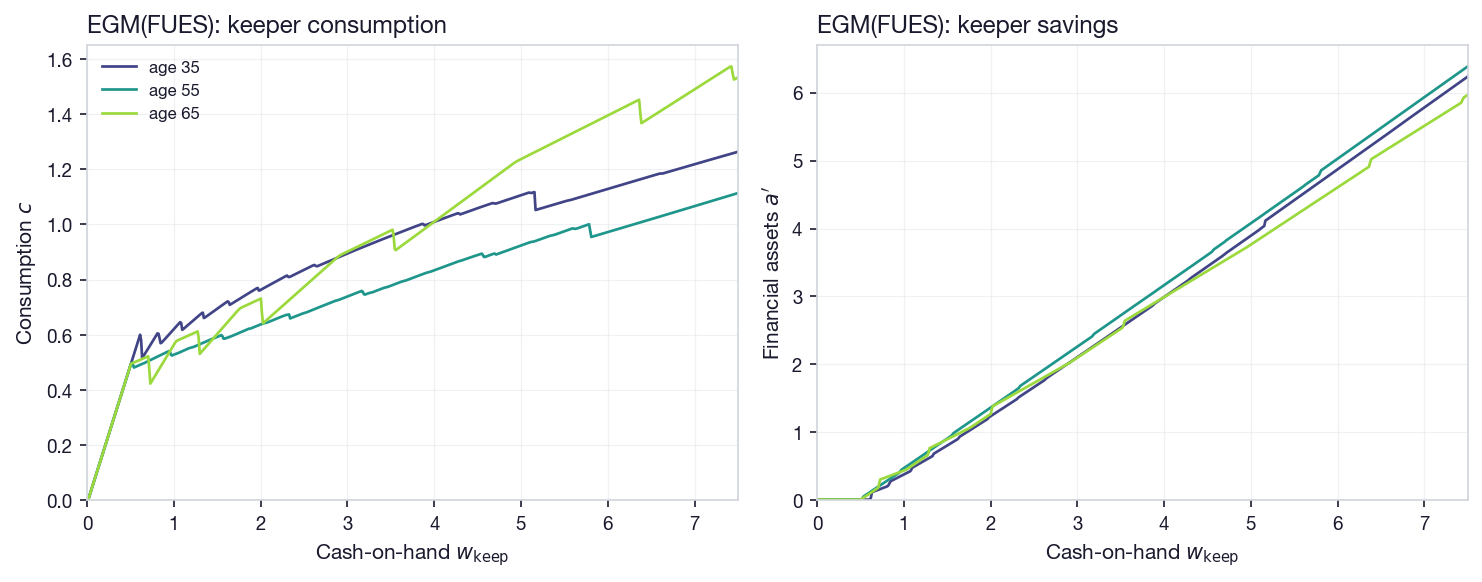

In [7]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[35, 55, 65], methods_filter=['FUES'])

NEGM(FUES) keeper — same 1D EGM + FUES kernel, so policies should be nearly identical to EGM(FUES).

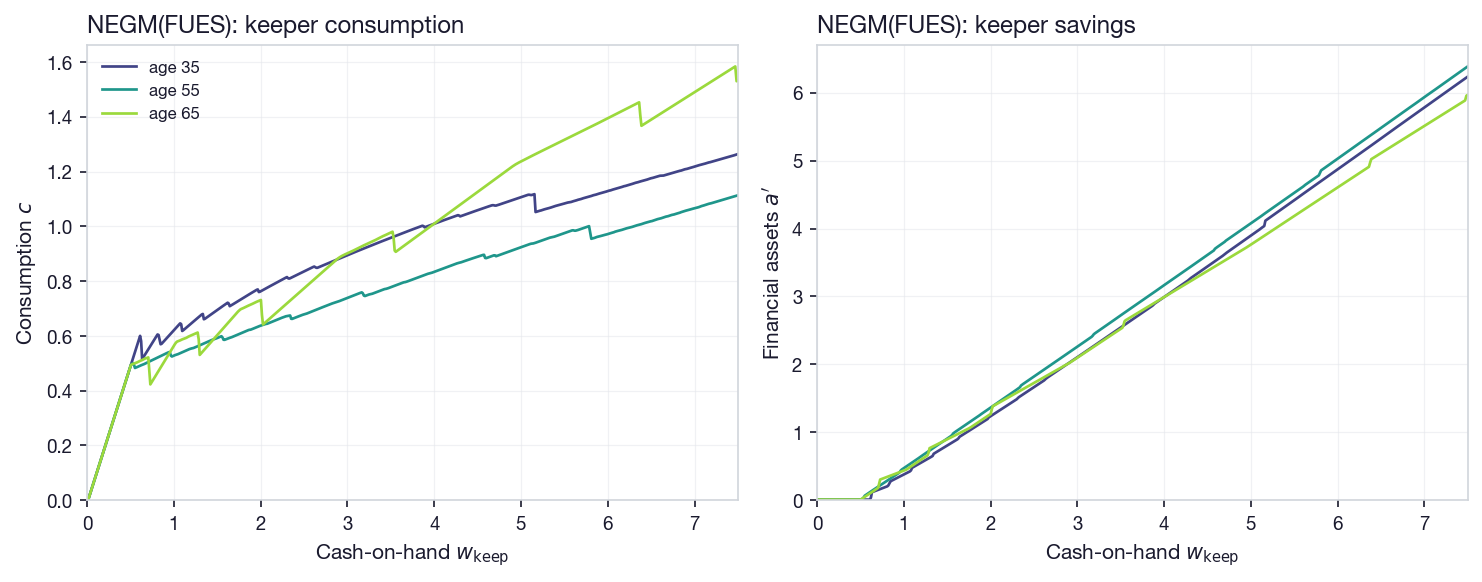

In [8]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[35, 55, 65], methods_filter=['NEGM'])

## 6. Euler equation errors

We forward-simulate 10,000 agents and evaluate two Euler residuals — one for the liquid asset and one for the durable — measured as $\log_{10}$ relative error ($-4$ = four digits of accuracy). We assume agents start with an average of $\$ 50,000$ in cash-on-hand.

**Consumption FOC** (all agents): $\partial_c\,\mathrm{u}(c, H_{\succ}) = \partial_a\,\mathrm{v}_{\succ}(a_{\succ}, H_{\succ})$, where $\mathrm{v}_{\succ}$ is the continuation value. Since the keeper stage is identical under both methods, keeper errors are similar.

**Housing FOC** (adjusters only): $(1{+}\tau)\,\partial_c\,\mathrm{u}(c, H_{\succ}) = \partial_H\,\mathrm{v}_{\succ}(a_{\succ}, H_{\succ})$. The factor $(1+\tau)$ reflects the proportional adjustment cost. This is where the methods diverge: EGM(FUES) inverts this FOC via root-finding and applies FUES to the resulting candidates; NEGM(FUES) maximises the adjuster objective numerically via golden-section search, nesting the keeper policy.

In [9]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(
        r['nest'], r['grids'],
        N=10_000, seed=41, init_dispersion=0.11)
    euler_c = evaluate_euler_c(
        sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(
        sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c,
        'euler_h': euler_h,
        'euler': euler_c,
        'stats_c': compute_euler_stats(
            euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(
            euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(
            euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


Left: keeper consumption FOC (methods nearly identical). Right: adjuster housing FOC, where EGM(FUES) gains roughly between one and two orders of magnitude in accuracy over NEGM(FUES).

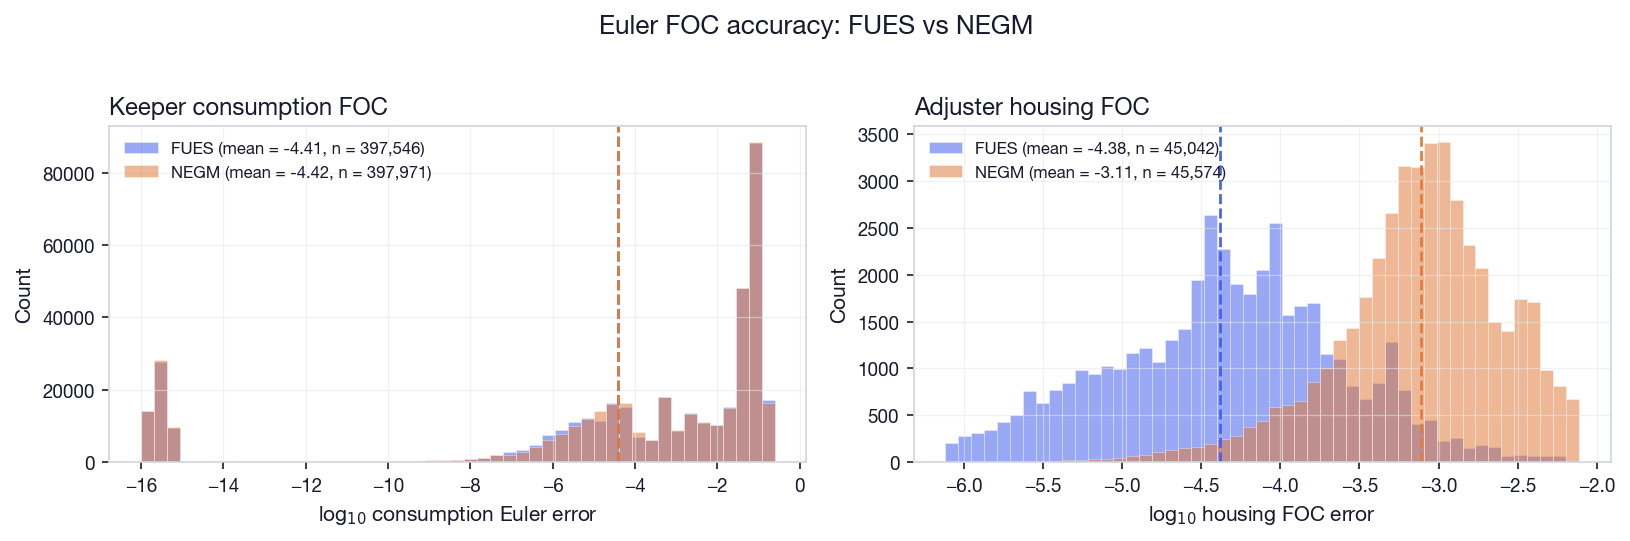

In [10]:
fig = plot_euler_histogram(euler_results)

### Welfare distribution

Per-agent certainty-equivalent utility at the start of the lifecycle, computed from the discounted NPV of flow utilities over the lifecycle.

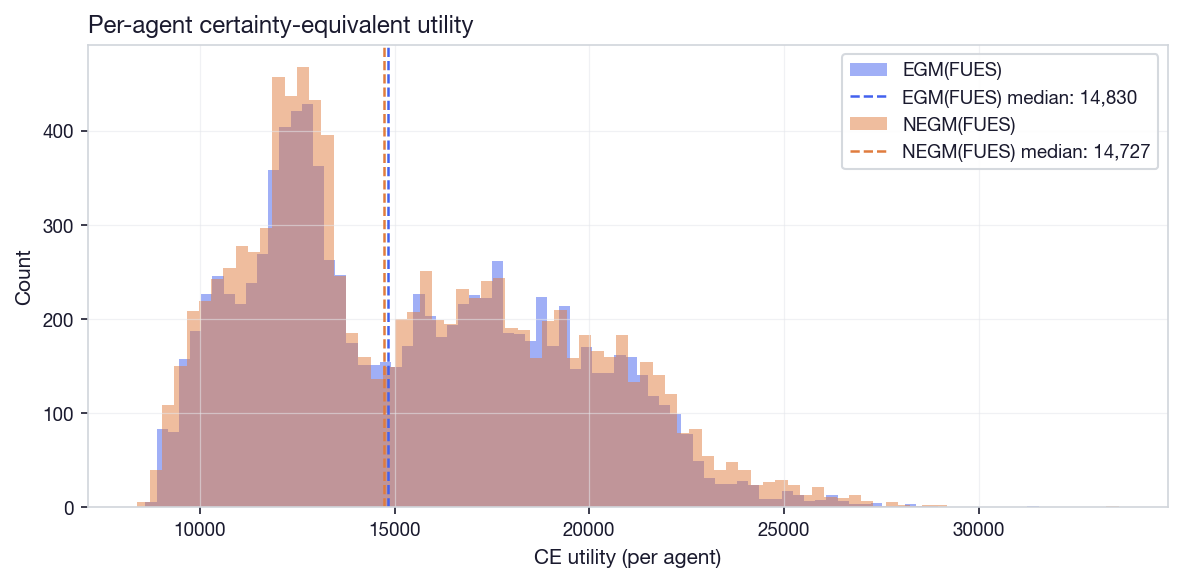

In [11]:
# Per-agent CE utility histogram
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0][
    'stages']['keeper_cons']
_rho = float(_st.calibration.get(
    'gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data'][
        'npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(
        inner > 0,
        inner ** (1.0 / (1.0 - _rho)),
        np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(
        ce, bins=80, alpha=0.5,
        label=_labels[method],
        color=_colors[method])
    ax.axvline(
        np.median(ce), color=_colors[method],
        ls='--', lw=1.2,
        label=f'{_labels[method]} median:'
              f' {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title(
    'Per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Comparison of errors and aggregates

The advantage of EGM FUES in the adjuster problem here is one to two orders of magnitude in accuracy over NEGM(FUES). Because FUES is already used for the keeper problem, the overall improvement in speed is modest (and will depend on the choice of numerical optimization used in the adjuster stage).

In [12]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 233 | 238 |
| Adjuster (ms/period) | 71 | 71 |
| Total (ms/period) | 1086 | 1134 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -4.41 | -4.42 |
| Consumption: adjuster | -4.24 | -4.19 |
| Consumption: all | -4.39 | -4.40 |
| Housing: adjuster | -4.38 | -3.11 |
| **Simulation** |  |  |
| CE utility | 14,206.45 | 14,194.24 |
| Mean consumption ($) | 61,995 | 61,994 |
| Mean fin. assets ($) | 37,420 | 37,713 |
| Mean housing ($) | 191,050 | 190,783 |
| Adjustment rate (%) | 12.6 | 12.4 |

## 8. Lifecycle profiles

Mean consumption, financial assets, and housing over the lifecycle. Both methods produce nearly identical aggregate profiles.

The difference between EGM and NEGM is more substantial towards the end of the lifecycle, where adjustment rates are higher.

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


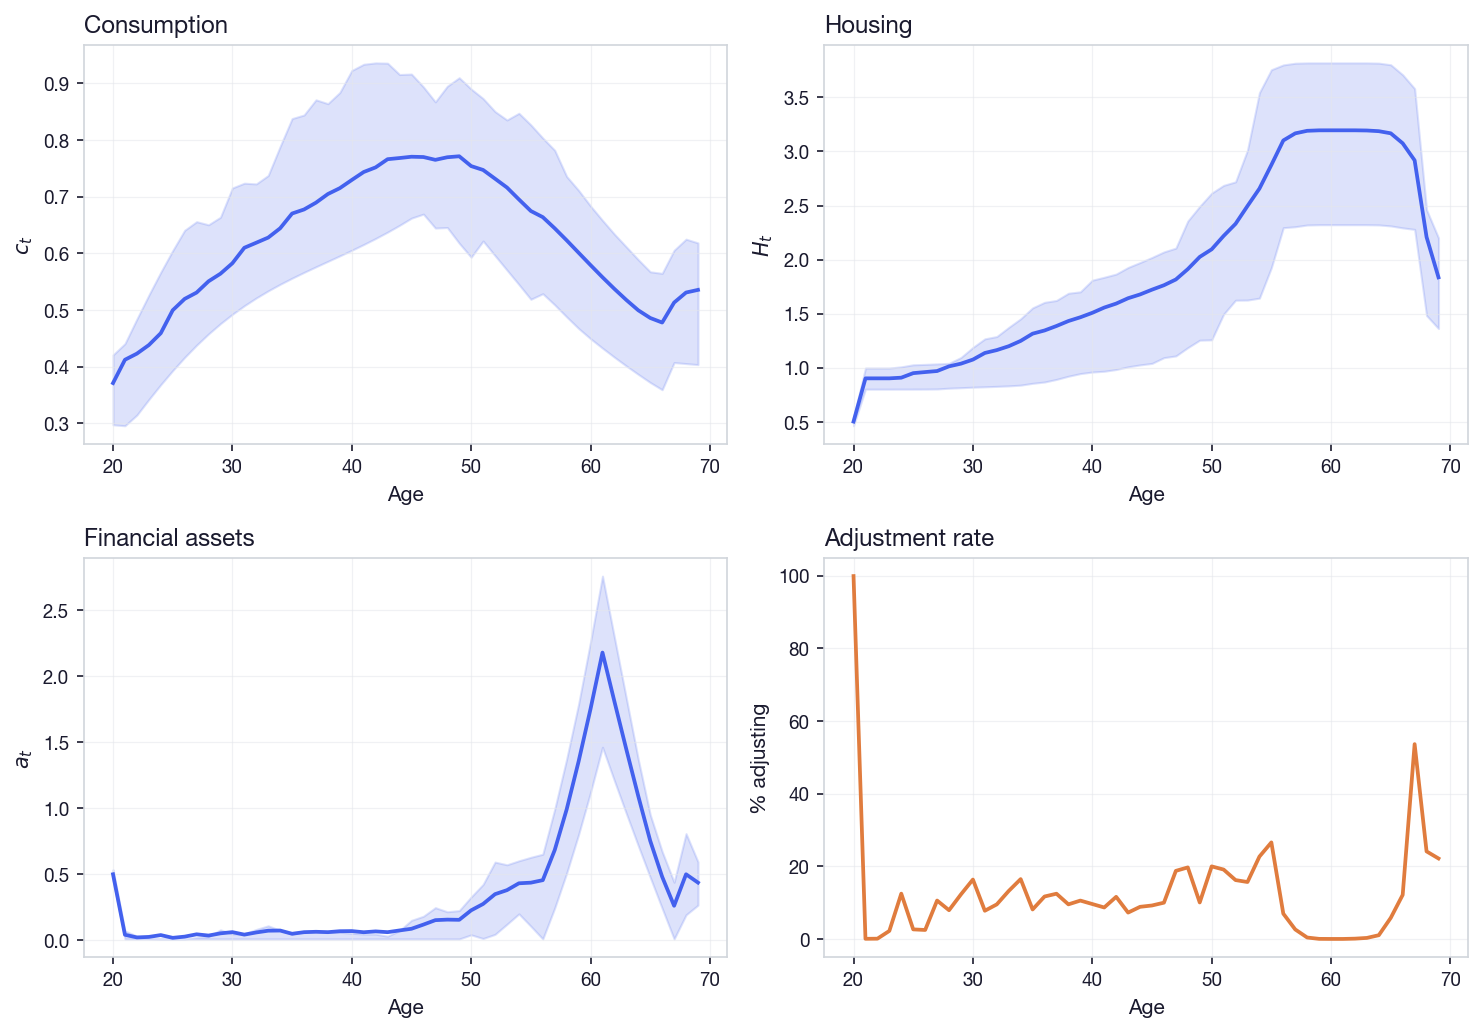

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


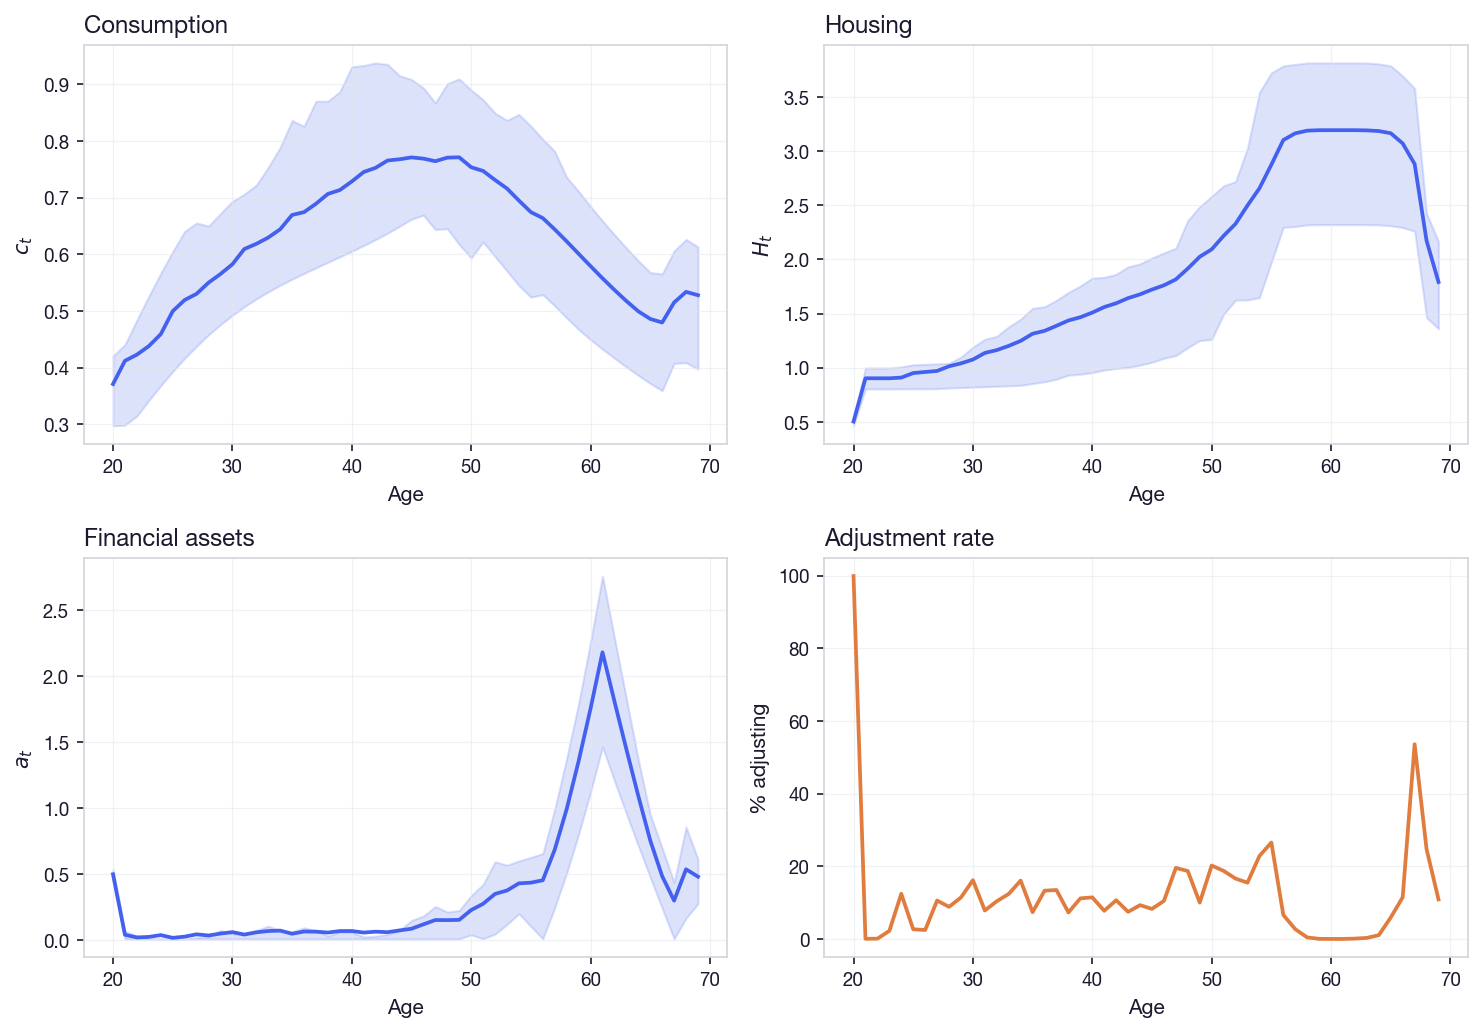

In [13]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

Simulation moments by 5-year age cohort (mean and SD of consumption, financial assets, and housing, in dollars).

In [14]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 42,072.06 | 14,369.47 | 12,546.92 | 19,328.46 | 82,286.95 | 19,793.78 |
| 25–29 | 53,291.89 | 16,101.00 | 3,578.47 | 6,563.58 | 98,576.11 | 27,263.27 |
| 30–34 | 61,659.88 | 16,606.83 | 6,189.48 | 10,254.28 | 116,421.66 | 44,794.75 |
| 35–39 | 69,131.16 | 18,756.46 | 6,088.05 | 10,546.78 | 138,864.60 | 59,360.75 |
| 40–44 | 75,173.30 | 18,944.96 | 6,658.57 | 12,585.15 | 159,543.03 | 69,222.72 |
| 45–49 | 76,918.15 | 17,799.52 | 13,383.27 | 18,955.26 | 184,743.64 | 79,648.48 |
| 50–54 | 72,875.98 | 17,429.10 | 33,235.16 | 31,756.86 | 235,944.03 | 97,654.63 |
| 55–59 | 64,131.88 | 16,915.41 | 78,403.48 | 61,966.29 | 310,630.97 | 99,752.83 |
| 60–64 | 53,827.64 | 14,543.49 | 165,492.26 | 77,988.53 | 319,375.74 | 93,918.68 |
| 65–69 | 50,865.44 | 13,715.66 | 48,625.62 | 39,848.97 | 264,116.21 | 98,952.72 |

**NEGM(FUES)**

| Age | Mean c | SD c | Mean a | SD a | Mean H | SD H |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| 20–24 | 42,069.57 | 14,374.54 | 12,542.91 | 19,329.69 | 82,297.74 | 19,790.14 |
| 25–29 | 53,295.94 | 16,104.71 | 3,549.85 | 6,536.44 | 98,629.96 | 27,250.14 |
| 30–34 | 61,687.22 | 16,614.54 | 6,161.46 | 10,234.89 | 116,417.17 | 44,786.22 |
| 35–39 | 69,069.97 | 18,741.02 | 6,174.71 | 10,620.29 | 138,827.82 | 59,409.10 |
| 40–44 | 75,204.75 | 19,006.06 | 6,580.95 | 12,512.72 | 159,649.25 | 69,208.49 |
| 45–49 | 76,929.59 | 17,773.72 | 13,363.72 | 18,951.11 | 184,748.40 | 79,643.68 |
| 50–54 | 72,869.56 | 17,419.32 | 33,275.46 | 31,717.01 | 235,888.03 | 97,695.92 |
| 55–59 | 64,132.58 | 16,896.86 | 78,534.12 | 61,946.20 | 310,517.82 | 99,773.94 |
| 60–64 | 53,830.09 | 14,531.21 | 165,733.21 | 77,925.37 | 319,194.61 | 94,059.96 |
| 65–69 | 50,851.40 | 13,719.57 | 51,218.04 | 40,617.10 | 261,663.14 | 99,970.63 |

---

*Source: `examples/durables/` — Dobrescu and Shanker (2026), Application 2*